In [ ]:
!pip install unidecode -q
!pip install rdkit -q

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import unidecode
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import json
import csv
import gzip
import urllib.request
from collections import defaultdict, Counter
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, QED, AllChem, DataStructs
import warnings
warnings.filterwarnings('ignore')

TOKENIZER_NAME = "bpe"

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
# Load and preprocess data
try:
    text = unidecode.unidecode(open('data_for_generation_mol.txt').read())
    print(f"✅ Data loaded: {len(text):,} characters")
except:
    print("⚠️ Data file not found. Please update the file path.")

unique_chars = len(set(text))
print(f"📊 Unique characters: {unique_chars}")
print(f"🔤 First 200 characters:\n{text[:200]}\n")
print(f"🧪 Number of molecules (approx, by '<' count): {text.count('<'):,}")

✅ Data loaded: 75,602,998 characters
📊 Unique characters: 57
🔤 First 200 characters:
<COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56><C[S+]([O-])c1ccc(cc1)c2nc(c3ccc(F)cc3)c([nH]2)c4ccncc4><CC1(C)Oc2ccc(cc2[C@H]([C@@H]1O)N3CCCC3=O)C#N><OC(

🧪 Number of molecules (approx, by '<' count): 1,498,669


## Tokenization (Byte Pair Encoding )

In [ ]:
class BPETokenizer:

    def __init__(self, num_merges=1000):
        self.num_merges = num_merges
        self.vocab = {}
        self.merges = {}
        self.special_tokens = ['<PAD>', '<UNK>', '<', '>']

    def get_stats(self, tokens):
        pairs = defaultdict(int)
        for i in range(len(tokens) - 1):
            pairs[(tokens[i], tokens[i+1])] += 1
        return pairs

    def merge_pair(self, tokens, pair, new_token):
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) == pair:
                new_tokens.append(new_token)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        return new_tokens

    def train(self, text):
        tokens = list(text)
        self.vocab = {token: idx for idx, token in enumerate(sorted(set(tokens)))}
        for token in self.special_tokens:
            if token not in self.vocab:
                self.vocab[token] = len(self.vocab)
        print(f"Initial vocabulary size: {len(self.vocab)}")

        for merge_idx in range(self.num_merges):
            pairs = self.get_stats(tokens)
            if not pairs:
                print(f"No more pairs to merge at iteration {merge_idx}")
                break

            valid_pairs = {p: c for p, c in pairs.items()
                           if not any('<' in tok or '>' in tok for tok in p)}
            if not valid_pairs:
                print(f"No more valid (non-boundary-crossing) pairs to merge at iteration {merge_idx}")
                break
            best_pair = max(valid_pairs, key=valid_pairs.get)
            new_token = ''.join(best_pair)
            self.merges[best_pair] = new_token
            if new_token not in self.vocab:
                self.vocab[new_token] = len(self.vocab)
            tokens = self.merge_pair(tokens, best_pair, new_token)
            if (merge_idx + 1) % 100 == 0:
                print(f"  Merge {merge_idx + 1}/{self.num_merges}: {best_pair} -> '{new_token}' (freq: {pairs[best_pair]})")

        print(f"Training complete! Final vocabulary size: {len(self.vocab)}")
        return self

    def encode(self, text):
        tokens = list(text)
        for pair, new_token in self.merges.items():
            tokens = self.merge_pair(tokens, pair, new_token)
        indices = []
        for token in tokens:
            if token in self.vocab:
                indices.append(self.vocab[token])
            else:
                indices.append(self.vocab.get('<UNK>', 0))
        return indices

    def decode(self, indices):
        idx_to_token = {idx: token for token, idx in self.vocab.items()}
        tokens = [idx_to_token.get(idx, '<UNK>') for idx in indices]
        return ''.join(tokens)

    def save(self, filepath):
        torch.save({
            'vocab': self.vocab,
            'merges': self.merges,
            'num_merges': self.num_merges,
            'special_tokens': self.special_tokens
        }, filepath)
        print(f"Tokenizer saved to {filepath}")

    def load(self, filepath):
        checkpoint = torch.load(filepath)
        self.vocab = checkpoint['vocab']
        self.merges = checkpoint['merges']
        self.num_merges = checkpoint['num_merges']
        self.special_tokens = checkpoint['special_tokens']
        print(f"Tokenizer loaded from {filepath}")
        return self

In [ ]:
num_merges = 2000
print(f"🎯 Using: {num_merges} merges")
print(f"📈 Expected vocab size: ~{unique_chars + num_merges}")

tokenizer = BPETokenizer(num_merges=num_merges)
tokenizer.train(text)

vocab_size = len(tokenizer.vocab)
print(f"\n📏 Final vocabulary size: {vocab_size}")

print("\n🔍 Sample learned tokens (showing multi-character tokens):")
multi_char_tokens = [(token, idx) for token, idx in tokenizer.vocab.items() if len(token) > 1]
multi_char_tokens = sorted(multi_char_tokens, key=lambda x: len(x[0]), reverse=True)[:20]
for token, idx in multi_char_tokens:
    print(f"  '{token}' -> {idx}")

🎯 Using: 2000 merges
📈 Expected vocab size: ~2057
Initial vocabulary size: 59
  Merge 100/2000: ('CC', '(=O)N') -> 'CC(=O)N' (freq: 87372)
  Merge 200/2000: ('C(F)(F)', 'F)') -> 'C(F)(F)F)' (freq: 33348)
  Merge 300/2000: ('\\N=C', '\\') -> '\N=C\' (freq: 17162)
  Merge 400/2000: ('C[C@H]', '1') -> 'C[C@H]1' (freq: 11773)
  Merge 500/2000: ('I', ')') -> 'I)' (freq: 8668)
  Merge 600/2000: ('c2n', 'c3ccccc3') -> 'c2nc3ccccc3' (freq: 6774)
  Merge 700/2000: ('c2ccc(', 'NC(=O)') -> 'c2ccc(NC(=O)' (freq: 5575)
  Merge 800/2000: ('c2ccc3', 'OCO') -> 'c2ccc3OCO' (freq: 4760)
  Merge 900/2000: ('S(=O)(=O)N', ')') -> 'S(=O)(=O)N)' (freq: 3996)
  Merge 1000/2000: ('OC', 'c3ccccc3)') -> 'OCc3ccccc3)' (freq: 3472)
  Merge 1100/2000: ('c(N)', 'ncn') -> 'c(N)ncn' (freq: 3039)
  Merge 1200/2000: ('[C@H](C', 'O)') -> '[C@H](CO)' (freq: 2703)
  Merge 1300/2000: ('N4', 'CCOCC4)') -> 'N4CCOCC4)' (freq: 2455)
  Merge 1400/2000: ('Cc1ccc(cc1)', 'S(=O)(=O)N') -> 'Cc1ccc(cc1)S(=O)(=O)N' (freq: 2216)
  Merge

In [ ]:
# Full dataset encoding
print("="*70)
print("📈 ENCODING FULL DATASET")
print("="*70)

encoded_data = tokenizer.encode(text)
data = torch.tensor(encoded_data, dtype=torch.long)

compression_ratio = len(text)/len(encoded_data)
print(f"Original text length: {len(text):,} characters")
print(f"Encoded data length: {len(encoded_data):,} tokens")
print(f"Compression ratio: {compression_ratio:.2f}x")
print(f"Dataset shape: {data.shape}, dtype: {data.dtype}")
print(f"First 30 tokens: {data[:30].tolist()}")

tokenizer_path = f'molecular_{TOKENIZER_NAME}_tokenizer.pt'
tokenizer.save(tokenizer_path)
print(f"Vocabulary size: {vocab_size}")
print(f"Encoded dataset size: {len(data):,} tokens")
print(f"Tokenizer saved to: {tokenizer_path}")

📈 ENCODING FULL DATASET
Original text length: 75,602,998 characters
Encoded data length: 16,636,869 tokens
Compression ratio: 4.54x
Dataset shape: torch.Size([16636869]), dtype: torch.int64
First 30 tokens: [18, 344, 256, 228, 32, 351, 427, 1246, 1132, 67, 206, 13, 82, 12, 1274, 92, 14, 91, 467, 328, 64, 15, 1208, 14, 20, 18, 24, 1032, 133, 308]
Tokenizer saved to molecular_bpe_tokenizer.pt
Vocabulary size: 2059
Encoded dataset size: 16,636,869 tokens
Tokenizer saved to: molecular_bpe_tokenizer.pt


## Data Splitting and Batch Generation

In [ ]:
# Hyperparameters (fixed across ALL tokenizer conditions for a fair, controlled comparison)
batch_size = 32
block_size = 256
learning_rate = 1e-4
n_head = 12
n_embd = n_head * 32
ff_size_factor = 4
n_layer = 12
dropout = 0.15

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Using device: {device}")

🖥️ Using device: cuda


In [ ]:
# Split data into train/validation
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"📊 Train data: {len(train_data):,} tokens")
print(f"📊 Val data: {len(val_data):,} tokens")

📊 Train data: 14,973,182 tokens
📊 Val data: 1,663,687 tokens


In [ ]:
def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# Sanity check
xb, yb = get_batch('train')
print(f"🔢 Batch shapes -> Input: {xb.shape}, Target: {yb.shape}")
print(f"\n📝 Sample decoded training sequence:")
print(f"  Input:  '{tokenizer.decode(xb[0][:20].cpu().tolist())}'")
print(f"  Target: '{tokenizer.decode(yb[0][:20].cpu().tolist())}'")

🔢 Batch shapes -> Input: torch.Size([32, 256]), Target: torch.Size([32, 256])

📝 Sample decoded training sequence:
  Input:  '<Oc1ccc(c(O)c1)c2ccc3c(O)cccc3c2><COc1ccc(cc1OC)c2ccc3c(O)cccc3c2><COc1cc(ccc1O)c2ccc3'
  Target: 'Oc1ccc(c(O)c1)c2ccc3c(O)cccc3c2><COc1ccc(cc1OC)c2ccc3c(O)cccc3c2><COc1cc(ccc1O)c2ccc3c(O)'


## Model Architecture

In [ ]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, ff_size_factor * n_embd),
            nn.GELU(),
            nn.Linear(ff_size_factor * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class DrugGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens, eos_token, temperature=1.0, top_k=None):
        self.eval()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                idx_cond = idx[:, -block_size:]
                logits, _ = self(idx_cond)
                logits = logits[:, -1, :] / temperature
                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)
                if idx_next.item() == eos_token:
                    break
                idx = torch.cat((idx, idx_next), dim=1)
        self.train()
        return idx

model = DrugGPT()
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🔧 Model created successfully!")
print(f"📊 Total parameters: {total_params/1e6:.2f}M")
print(f"🏋️ Trainable parameters: {trainable_params/1e6:.2f}M")
print(f"💾 Model size: ~{total_params * 4 / 1e6:.1f}MB")

🔧 Model created successfully!
📊 Total parameters: 22.96M
🏋️ Trainable parameters: 22.96M
💾 Model size: ~91.8MB


## Training configuration & effective-epoch calculation



In [ ]:
# Training hyperparameters
max_iters = 25000
eval_interval = 200
eval_iters = 100
save_interval = 1000
save_path = f"drugGPT_{TOKENIZER_NAME}.pt"

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=learning_rate*0.1)

tokens_per_step = batch_size * block_size
total_tokens_sampled = tokens_per_step * max_iters
effective_epochs = total_tokens_sampled / len(train_data)
estimated_unique_coverage = 1 - math.exp(-total_tokens_sampled / len(train_data))

print(f"📐 Tokenizer: {TOKENIZER_NAME}")
print(f"📐 Vocabulary size: {vocab_size}")
print(f"📐 num_merges: {num_merges}")
print(f"📐 Compression ratio (chars/token): {compression_ratio:.2f}x")
print(f"📐 Training set size: {len(train_data):,} tokens")
print(f"📐 Tokens sampled per training step: {tokens_per_step:,}")
print(f"📐 Total tokens sampled over {max_iters:,} steps: {total_tokens_sampled:,}")
print(f"📐 Effective epochs (tokens sampled / train set size): {effective_epochs:.2f}")
print(f"📐 Estimated unique-position coverage: {estimated_unique_coverage*100:.1f}%")

training_config = {
    "tokenizer": TOKENIZER_NAME,
    "vocab_size": vocab_size,
    "num_merges": num_merges,
    "compression_ratio": round(compression_ratio, 3),
    "train_set_size_tokens": len(train_data),
    "val_set_size_tokens": len(val_data),
    "batch_size": batch_size,
    "block_size": block_size,
    "learning_rate": learning_rate,
    "n_head": n_head,
    "n_embd": n_embd,
    "n_layer": n_layer,
    "dropout": dropout,
    "optimizer": "AdamW",
    "weight_decay": 0.01,
    "lr_scheduler": "CosineAnnealingLR",
    "max_iters": max_iters,
    "effective_epochs": round(effective_epochs, 3),
    "estimated_unique_coverage_pct": round(estimated_unique_coverage*100, 2),
    "total_params_M": round(total_params/1e6, 3),
}
with open(f"training_config_{TOKENIZER_NAME}.json", "w") as f:
    json.dump(training_config, f, indent=2)
print(f"\n💾 Saved training_config_{TOKENIZER_NAME}.json")

📐 Tokenizer: bpe
📐 Vocabulary size: 2059
📐 num_merges: 2000
📐 Compression ratio (chars/token): 4.54x
📐 Training set size: 14,973,182 tokens
📐 Tokens sampled per training step: 8,192
📐 Total tokens sampled over 25,000 steps: 204,800,000
📐 Effective epochs (tokens sampled / train set size): 13.68
📐 Estimated unique-position coverage: 100.0%

💾 Saved training_config_bpe.json


In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

def generate_smiles(model, n_samples=100, temperature=0.8, max_length=100):
    sos_token = tokenizer.encode('<')[0]
    eos_token = tokenizer.encode('>')[0]
    generated_smiles = []
    context = torch.tensor([[sos_token]], dtype=torch.long, device=device)
    for i in range(n_samples):
        try:
            generated = model.generate(context, max_new_tokens=max_length, eos_token=eos_token,
                                        temperature=temperature, top_k=50)
            smi = tokenizer.decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()
            if smi and len(smi) > 5:
                generated_smiles.append(smi)
        except Exception:
            continue
    return generated_smiles

## Training Loop



🚀 Starting training for 25000 iterations...
📊 Batch size: 32, Block size: 256
🧠 Model: 23.0M parameters
Step     0 | Train: 7.7308 | Val: 7.7309 | LR: 1.00e-04 | Time: 14.7s
💾 Checkpoint saved at iteration 0
Step   200 | Train: 5.2855 | Val: 5.3726 | LR: 1.00e-04 | Time: 76.9s
Step   400 | Train: 4.7781 | Val: 4.8895 | LR: 9.99e-05 | Time: 138.8s
Step   600 | Train: 4.5048 | Val: 4.6382 | LR: 9.99e-05 | Time: 200.8s
Step   800 | Train: 4.3098 | Val: 4.4559 | LR: 9.98e-05 | Time: 262.1s
Step  1000 | Train: 4.1519 | Val: 4.3110 | LR: 9.96e-05 | Time: 324.1s
💾 Checkpoint saved at iteration 1000
Step  1200 | Train: 3.9469 | Val: 4.1024 | LR: 9.95e-05 | Time: 387.7s
Step  1400 | Train: 3.7179 | Val: 3.8910 | LR: 9.93e-05 | Time: 449.6s
Step  1600 | Train: 3.5412 | Val: 3.7154 | LR: 9.91e-05 | Time: 510.9s
Step  1800 | Train: 3.3908 | Val: 3.5794 | LR: 9.89e-05 | Time: 572.9s
Step  2000 | Train: 3.2843 | Val: 3.4842 | LR: 9.86e-05 | Time: 634.6s
💾 Checkpoint saved at iteration 2000
Step  220

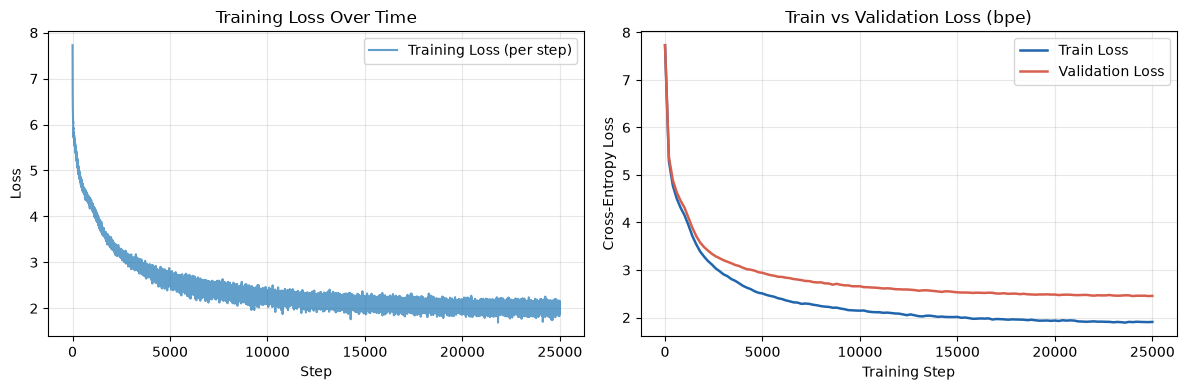

📊 Final Training Loss: 1.9078
📊 Final Validation Loss: 2.4555
💾 Updated training_config_bpe.json with final loss values

🧪 Quick generation sanity check...
Generated samples: ['CN(C)c1cc(ccn1)c2c[nH]c(n2)c3ccc(Cl)cc3', 'COc1ccc(CN2CCCC(C2)C(=O)c3ccc(cc3)S(=O)(=O)N)cc1', 'Fc1ccc2c(sc2c1)c3nc4ncccc4n3CCC(=O)NCC5CC5', 'OC(=O)CNC(=O)CCCCc1ccccc1', 'COc1ncc(cn1)c2cnc(cn2)c3cnc(cn3)c4cnc(cn4)c5cnc(cs5)C(=O)OC6CC6.CS(=O)(=O)O']


In [ ]:
resume_training = os.path.exists(save_path)
start_iter = 0

if resume_training:
    print(f"🔄 Resuming from checkpoint: {save_path}")
    try:
        checkpoint = torch.load(save_path, map_location=device)
        if isinstance(checkpoint, dict):
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_iter = checkpoint.get('iteration', 0)
            print(f"📍 Resuming from iteration {start_iter}")
        else:
            model = checkpoint
            model.to(device)
            print("📍 Loaded legacy checkpoint")
    except Exception as e:
        print(f"⚠️ Error loading checkpoint: {e}")
        print("🔄 Starting fresh training...")
        resume_training = False

losses = []
train_losses = []
val_losses = []
eval_step_numbers = []
start_time = time.time()

print(f"🚀 Starting training for {max_iters} iterations...")
print(f"📊 Batch size: {batch_size}, Block size: {block_size}")
print(f"🧠 Model: {trainable_params/1e6:.1f}M parameters")

for iter_num in range(start_iter, max_iters):
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        losses_dict = estimate_loss()
        train_loss = losses_dict['train']
        val_loss = losses_dict['val']
        train_losses.append(float(train_loss))
        val_losses.append(float(val_loss))
        eval_step_numbers.append(iter_num)
        elapsed_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Step {iter_num:5d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"LR: {current_lr:.2e} | Time: {elapsed_time:.1f}s")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())

    if iter_num % save_interval == 0 or iter_num == max_iters - 1:
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'iteration': iter_num,
            'eval_step_numbers': eval_step_numbers,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'config': {
                'vocab_size': vocab_size, 'block_size': block_size, 'n_embd': n_embd,
                'n_head': n_head, 'n_layer': n_layer, 'dropout': dropout,
            }
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at iteration {iter_num}")

total_time = time.time() - start_time
print(f"\n✅ Training completed!")
print(f"⏱️ Total training time: {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"🚀 Average time/iteration: {total_time/max_iters:.3f}s")

# --- Save raw loss-curve data to CSV ---
csv_path = f"loss_curve_data_{TOKENIZER_NAME}.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "train_loss", "val_loss"])
    for s, tr, va in zip(eval_step_numbers, train_losses, val_losses):
        writer.writerow([s, tr, va])
print(f"💾 Saved raw loss curve data: {csv_path}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, alpha=0.7, label='Training Loss (per step)')
plt.title('Training Loss Over Time'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(eval_step_numbers, train_losses, '-', color='#2166AC', linewidth=1.8, label='Train Loss')
plt.plot(eval_step_numbers, val_losses, '-', color='#D6604D', linewidth=1.8, label='Validation Loss')
plt.title(f'Train vs Validation Loss ({TOKENIZER_NAME})')
plt.xlabel('Training Step'); plt.ylabel('Cross-Entropy Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"loss_curve_{TOKENIZER_NAME}.png", dpi=300)
plt.show()

print(f"📊 Final Training Loss: {train_losses[-1]:.4f}")
print(f"📊 Final Validation Loss: {val_losses[-1]:.4f}")

training_config.update({
    "final_train_loss": round(float(train_losses[-1]), 4),
    "final_val_loss": round(float(val_losses[-1]), 4),
    "total_training_time_sec": round(total_time, 1),
})
with open(f"training_config_{TOKENIZER_NAME}.json", "w") as f:
    json.dump(training_config, f, indent=2)
print(f"💾 Updated training_config_{TOKENIZER_NAME}.json with final loss values")

print(f"\n🧪 Quick generation sanity check...")
test_samples = generate_smiles(model, n_samples=10, temperature=0.8)
print(f"Generated samples: {test_samples[:5]}")

## Evaluation setup: QED / SA score dependencies

In [ ]:
sascorer_path = "sascorer.py"
fpscores_path = "fpscores.pkl.gz"

if not os.path.exists(sascorer_path):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py",
        sascorer_path)
if not os.path.exists(fpscores_path):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz",
        fpscores_path)

sys.path.append(os.getcwd())
import sascorer

_test_mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
print(f"✅ SA score sanity check (aspirin): {sascorer.calculateScore(_test_mol):.3f}")
print(f"✅ QED sanity check (aspirin): {QED.qed(_test_mol):.3f}")

✅ SA score sanity check (aspirin): 1.580
✅ QED sanity check (aspirin): 0.550


In [ ]:
from utils import (
    n_chars,
    check_validity,
    check_novelty,
    strsmis2listsmis,
    list2txt,
    get_props,
)

def load_training_smiles(file_path):
    try:
        with open(file_path, 'r') as f:
            text = f.read()
        training_smiles = []
        current_smi = ""
        in_smiles = False
        for char in text:
            if char == '<':
                in_smiles = True
                current_smi = ""
            elif char == '>':
                if in_smiles and current_smi:
                    training_smiles.append(current_smi)
                in_smiles = False
                current_smi = ""
            elif in_smiles:
                current_smi += char
        print(f"Loaded {len(training_smiles)} training SMILES")
        return list(set(training_smiles))
    except Exception as e:
        print(f"Error loading training data: {e}")
        return []

training_data_path = 'data_for_generation_mol.txt'
training_smiles = load_training_smiles(training_data_path)

Loaded 1498669 training SMILES


In [ ]:
def generate_diverse_smiles(model, n_samples=500, temperature_range=(0.7, 1.2), max_length=100, verbose=False):
    model.eval()
    sos_token = tokenizer.encode('<')[0]
    eos_token = tokenizer.encode('>')[0]
    generated_smiles = []
    for i in range(n_samples):
        temp = random.uniform(temperature_range[0], temperature_range[1])
        try:
            context = torch.tensor([[sos_token]], dtype=torch.long, device=device)
            generated = model.generate(context, max_new_tokens=max_length, eos_token=eos_token,
                                        temperature=temp, top_k=random.randint(30, 100))
            smi = tokenizer.decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()
            if smi and len(smi) > 5:
                generated_smiles.append(smi)
        except Exception:
            continue
        if verbose and i % 100 == 0:
            print(f"  Generated {i}/{n_samples}...")
    model.train()
    return generated_smiles

## Benchmark functions (validity → uniqueness → novelty, + QED/SA/MW)

In [ ]:
def check_validity_batch(smiles_list):
    valid_smiles = []
    for smi in smiles_list:
        if check_validity(smi):
            valid_smiles.append(smi)
    return valid_smiles

def check_uniqueness_correct(smiles_list):
    return list(set(smiles_list))

def check_novelty_correct(generated_smiles, training_smiles):
    novel_smiles = []
    training_set = set(training_smiles)
    for smi in generated_smiles:
        if smi not in training_set:
            novel_smiles.append(smi)
    return novel_smiles

def calculate_diversity_tanimoto(smiles_list, sample_size=1000):
    if len(smiles_list) < 2:
        return 0.0
    smiles_sample = random.sample(smiles_list, sample_size) if len(smiles_list) > sample_size else smiles_list
    fps = []
    for smi in smiles_sample:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=2048))
    if len(fps) < 2:
        return 0.0
    similarities = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            similarities.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return 1 - np.mean(similarities)

def compute_drug_likeness(smiles_list):
    count = 0
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                mw = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                hbd = Descriptors.NumHDonors(mol)
                hba = Descriptors.NumHAcceptors(mol)
                if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10:
                    count += 1
        except Exception:
            continue
    return count / len(smiles_list) if smiles_list else 0.0

def compute_qed_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(QED.qed(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

def compute_sa_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(sascorer.calculateScore(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

def compute_mw_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(Descriptors.MolWt(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

## Multi-run benchmark (10 runs × 500 molecules = 5,000 total generations)



In [ ]:
def run_multi_run_benchmark(model, n_runs=10, n_samples=500, save_prefix=None):
    save_prefix = save_prefix or TOKENIZER_NAME
    per_run_results = []

    for run_idx in range(n_runs):
        print(f"\n{'='*60}\nRUN {run_idx+1}/{n_runs}\n{'='*60}")
        generated = generate_diverse_smiles(model, n_samples=n_samples)
        print(f"Raw generated: {len(generated)}")

        valid = check_validity_batch(generated)
        validity = len(valid) / len(generated) if generated else 0.0
        print(f"Validity: {validity:.2%} ({len(valid)}/{len(generated)})")

        if not valid:
            per_run_results.append({
                "run": run_idx, "n_generated": len(generated), "validity": validity,
                "uniqueness": 0.0, "novelty": 0.0, "diversity": 0.0, "drug_likeness": 0.0,
                "qed_mean": 0.0, "sa_mean": 0.0, "mw_mean": 0.0,
            })
            continue

        unique = check_uniqueness_correct(valid)
        uniqueness = len(unique) / len(valid) if valid else 0.0
        print(f"Uniqueness: {uniqueness:.2%} ({len(unique)}/{len(valid)})")

        novel = check_novelty_correct(unique, training_smiles) if training_smiles else unique
        novelty = len(novel) / len(unique) if unique else 0.0
        print(f"Novelty: {novelty:.2%} ({len(novel)}/{len(unique)})")

        diversity = calculate_diversity_tanimoto(novel) if len(novel) > 1 else 0.0
        drug_likeness = compute_drug_likeness(novel)
        qed_stats = compute_qed_stats(novel)
        sa_stats = compute_sa_stats(novel)
        mw_stats = compute_mw_stats(novel)

        print(f"Diversity: {diversity:.4f} | Drug-likeness: {drug_likeness:.2%} | "
              f"QED: {qed_stats['mean']:.3f} | SA: {sa_stats['mean']:.3f} | MW: {mw_stats['mean']:.1f}")

        per_run_results.append({
            "run": run_idx, "n_generated": len(generated), "validity": validity,
            "uniqueness": uniqueness, "novelty": novelty, "diversity": diversity,
            "drug_likeness": drug_likeness,
            "qed_mean": qed_stats["mean"], "sa_mean": sa_stats["mean"], "mw_mean": mw_stats["mean"],
        })

    def agg(key):
        vals = [r[key] for r in per_run_results]
        return float(np.mean(vals)), float(np.std(vals))

    summary = {}
    for key in ["validity", "uniqueness", "novelty", "diversity", "drug_likeness",
                "qed_mean", "sa_mean", "mw_mean"]:
        mean, std = agg(key)
        summary[key] = {"mean": mean, "std": std}

    print(f"\n{'='*60}\nFINAL SUMMARY — {TOKENIZER_NAME} (n_runs={n_runs}, n_samples/run={n_samples})\n{'='*60}")
    for key, v in summary.items():
        print(f"{key:15s}: {v['mean']:.4f} ± {v['std']:.4f}")

    output = {
        "tokenizer": TOKENIZER_NAME,
        "n_runs": n_runs,
        "n_samples_per_run": n_samples,
        "per_run_results": per_run_results,
        "summary": summary,
    }
    with open(f"benchmark_results_{save_prefix}.json", "w") as f:
        json.dump(output, f, indent=2)
    print(f"\n💾 Saved benchmark_results_{save_prefix}.json")

    return output

## Load trained model and run the full benchmark

In [ ]:
def load_model(checkpoint_path, device=device):
    model = DrugGPT()
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict):
        state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    else:
        state_dict = checkpoint.state_dict()
    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    return model

model = load_model(f"drugGPT_{TOKENIZER_NAME}.pt")
print(f"✅ Loaded trained model: drugGPT_{TOKENIZER_NAME}.pt")

✅ Loaded trained model: drugGPT_bpe.pt


In [ ]:
results = run_multi_run_benchmark(model, n_runs=10, n_samples=500)


RUN 1/10
Raw generated: 500
Validity: 94.20% (471/500)
Uniqueness: 100.00% (471/471)
Novelty: 93.63% (441/471)
Diversity: 0.9107 | Drug-likeness: 85.26% | QED: 0.616 | SA: 2.707 | MW: 366.8

RUN 2/10
Raw generated: 500
Validity: 95.80% (479/500)
Uniqueness: 100.00% (479/479)
Novelty: 95.20% (456/479)
Diversity: 0.9070 | Drug-likeness: 84.87% | QED: 0.624 | SA: 2.633 | MW: 360.5

RUN 3/10
Raw generated: 500
Validity: 94.60% (473/500)
Uniqueness: 100.00% (473/473)
Novelty: 93.66% (443/473)
Diversity: 0.9094 | Drug-likeness: 83.97% | QED: 0.609 | SA: 2.707 | MW: 364.1

RUN 4/10
Raw generated: 500
Validity: 94.60% (473/500)
Uniqueness: 100.00% (473/473)
Novelty: 91.75% (434/473)
Diversity: 0.9123 | Drug-likeness: 82.49% | QED: 0.610 | SA: 2.656 | MW: 366.1

RUN 5/10
Raw generated: 500
Validity: 94.20% (471/500)
Uniqueness: 99.79% (470/471)
Novelty: 92.77% (436/470)
Diversity: 0.9087 | Drug-likeness: 82.57% | QED: 0.604 | SA: 2.683 | MW: 374.9

RUN 6/10
Raw generated: 500
Validity: 94.00% 